### AT&T Spam detector

But:
constuire un ou plusieurs modèles de Deep Learning permettant de prédire si le sms est un spam or ham


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import scipy.sparse as sp

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# TensorFlow
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizerFast, BertModel

# Fixer Seed pour la reproductibilité
SEED = 42
np.random.seed(SEED)      # Contrôle le hasard dans NumPy (train_test_split, TF-IDF...)

# Device : GPU si disponible, sinon CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Chargement du dataset
# Le fichier contient des colonnes (Unnamed) —> on ne garde que v1 (label) et v2 (texte)
df = pd.read_csv('/content/drive/MyDrive/data/spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
df.columns = ['label', 'text']

print(f'Dimensions : {df.shape}')
print(f'Valeurs manquantes :\n{df.isnull().sum()}')
df.head(10)

Dimensions : (5572, 2)
Valeurs manquantes :
label    0
text     0
dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


label
ham     4825
spam     747
Name: count, dtype: int64

Proportion spam : 13.4%


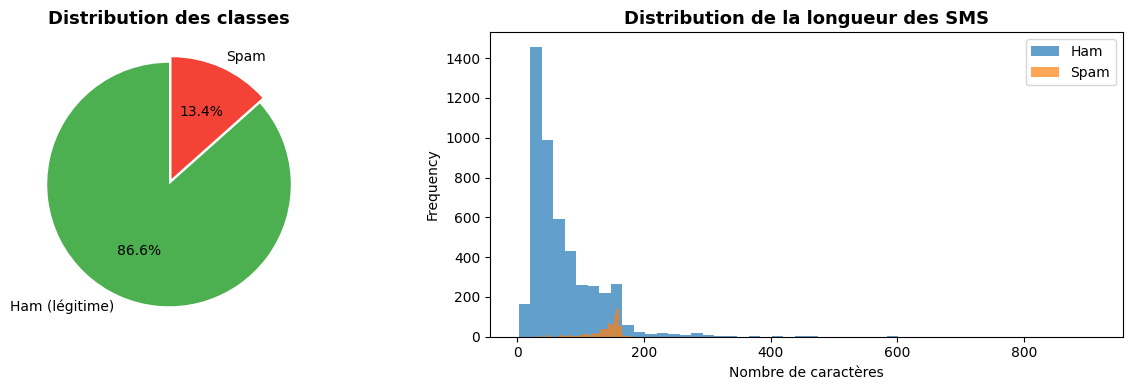

In [5]:
# Distribution des classes
print(df['label'].value_counts())
print(f"\nProportion spam : {df['label'].value_counts(normalize=True)['spam']:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Camembert
df['label'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    labels=['Ham (légitime)', 'Spam'],
    startangle=90, explode=[0, 0.05]
)
axes[0].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

# Longueur des messages
df['length'] = df['text'].apply(len)
df.groupby('label')['length'].plot.hist(ax=axes[1], bins=50, alpha=0.7)
axes[1].set_title('Distribution de la longueur des SMS', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de caractères')
axes[1].legend(['Ham', 'Spam'])

plt.tight_layout()
plt.show()

Le dataset est déséquilibré (87% ham, 13% spam)
→ On utilisera le F1-score comme métrique principale, plus pertinent que l'accuracy.

L'accuracy ignore les types d'erreurs Faux Négatifs et Faux positifs dès que la classe majoritaire domine.

Le F1-score combine deux métriques complémentaires sur la classe minoritaire (spam) :
- Précision — Parmi les messages classifiés spam, combien le sont vraiment ?
- Rappel — Parmi les vrais spams, combien sont détectés ?



### Traitement du texte

In [6]:
def clean_text(text):
    text = text.lower()                          # Minuscules
    text = re.sub(r'[^a-z0-9\s]', ' ', text)    # Supprime ponctuation et caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip()     # Normalise les espaces
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Encodage de la cible : spam = 1, ham = 0
df['target'] = (df['label'] == 'spam').astype(int)

print('Exemples après nettoyage :')
df[['text', 'text_clean', 'label']].head(5)

Exemples après nettoyage :


,text,text_clean,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,ham


In [7]:
# Split train / test (80% / 20%) avec stratification pour respecter la distribution des classes
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], df['target'],
    test_size=0.2, random_state=SEED, stratify=df['target']
)

print(f'Train : {len(X_train)} exemples | Test : {len(X_test)} exemples')
print(f"Spam dans train : {y_train.mean():.1%} | Spam dans test : {y_test.mean():.1%}")

Train : 4457 exemples | Test : 1115 exemples
Spam dans train : 13.4% | Spam dans test : 13.4%


### Modèle 1 — Régression Logistique + TF-IDF *(Baseline)*

- **TF-IDF** (Term Frequency–Inverse Document Frequency) transforme chaque SMS en vecteur numérique en pondérant les mots selon leur importance relative.
- La **Régression Logistique** est linéaire, rapide, interprétable, et fonctionne souvent très bien sur du texte.

In [8]:
# Vectorisation TF-IDF
# max_features=10000 : on garde les 10 000 mots les plus fréquents
# ngram_range=(1,2) : on inclut les bigrammes pour capturer des expressions comme "free prize"
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Entraînement
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced') #balanced pour compenser le déséquilibre des classes
lr.fit(X_train_tfidf, y_train)

# Évaluation
y_pred_lr = lr.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))
print(f'F1-Score (spam) : {f1_score(y_test, y_pred_lr):.4f}')


              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115

F1-Score (spam) : 0.9420


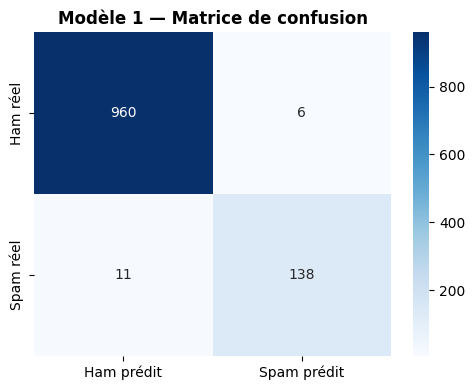

In [9]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham prédit', 'Spam prédit'],
            yticklabels=['Ham réel', 'Spam réel'])
plt.title('Modèle 1 — Matrice de confusion', fontweight='bold')
plt.tight_layout()
plt.show()

### Modèle 2 — Réseau de neurones dense (MLP) + TF-IDF
classifieur linéaire remplaclé par un réseau de neurones dense (Multi-Layer Perceptron).  
- Les couches Linear + ReLU -> apprentissage combinaisons non-linéaires de caractéristiques
- Le Dropout est utilisé pour réduire le surapprentissage (regularisation).

In [10]:
# Conversion par chunks pour éviter le pic mémoire
chunk_size = 500
chunks_train = []
for i in range(0, X_train_tfidf.shape[0], chunk_size):
    chunk = X_train_tfidf[i:i+chunk_size].toarray()
    chunks_train.append(torch.tensor(chunk, dtype=torch.float32))
X_train_dense = torch.cat(chunks_train, dim=0)

chunks_test = []
for i in range(0, X_test_tfidf.shape[0], chunk_size):
    chunk = X_test_tfidf[i:i+chunk_size].toarray()
    chunks_test.append(torch.tensor(chunk, dtype=torch.float32))
X_test_dense = torch.cat(chunks_test, dim=0)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)

class TFIDFDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_mlp = TFIDFDataset(X_train_dense, y_train_t)
test_dataset_mlp  = TFIDFDataset(X_test_dense,  y_test_t)

train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=16, shuffle=True, num_workers=0)
test_loader_mlp  = DataLoader(test_dataset_mlp,  batch_size=16, num_workers=0)

print(f'Taille du vecteur TF-IDF : {X_train_dense.shape[1]}')
print(f'Mémoire tenseur train    : {X_train_dense.element_size() * X_train_dense.nelement() / 1e6:.1f} MB')

Taille du vecteur TF-IDF : 10000
Mémoire tenseur train    : 178.3 MB


In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1     = nn.Linear(input_dim, 256)  # Couche dense : input_dim → 256 neurones
        self.relu1   = nn.ReLU()
        self.drop1   = nn.Dropout(p=0.3)          # Dropout 30% contre le surapprentissage
        self.fc2     = nn.Linear(256, 64)          # Couche dense : 256 → 64 neurones
        self.relu2   = nn.ReLU()
        self.drop2   = nn.Dropout(p=0.3)
        self.output  = nn.Linear(64, 1)            # Sortie : 1 neurone = score spam
        self.sigmoid = nn.Sigmoid()                # Convertit en probabilité [0, 1]

    def forward(self, x):
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.output(x))
        return x.squeeze(1)  # [batch, 1] → [batch]

MLP(
  (fc1): Linear(in_features=10000, out_features=256, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Époque 01/15 — Train Loss : 0.2070 | Val Loss : 0.0651
Époque 02/15 — Train Loss : 0.0237 | Val Loss : 0.0724
Époque 03/15 — Train Loss : 0.0055 | Val Loss : 0.0848
Époque 04/15 — Train Loss : 0.0020 | Val Loss : 0.0806
Époque 05/15 — Train Loss : 0.0014 | Val Loss : 0.0811
Époque 06/15 — Train Loss : 0.0013 | Val Loss : 0.0875
Époque 07/15 — Train Loss : 0.0014 | Val Loss : 0.0891
Époque 08/15 — Train Loss : 0.0012 | Val Loss : 0.0917
Époque 09/15 — Train Loss : 0.0013 | Val Loss : 0.0924
Époque 10/15 — Train Loss : 0.0011 | Val Loss : 0.0969
Époque 11/15 — Train Loss : 0.0012 | Val Loss : 0.1035
Époque 12/15 — Train Loss : 0.0011 | Val Loss : 0.1067
Époqu

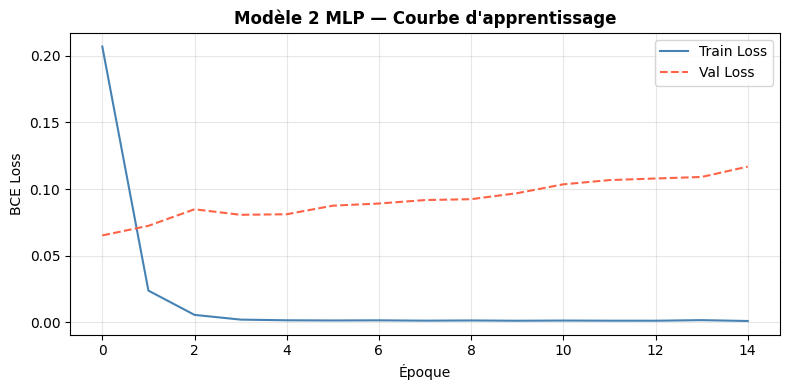

In [12]:
mlp = MLP(input_dim=X_train_tfidf.shape[1]).to(DEVICE)
print(mlp)

criterion_mlp = nn.BCELoss()  # Binary Cross-Entropy : loss standard pour classification binaire
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3)

EPOCHS = 15
train_losses_mlp = []
val_losses_mlp   = []

for epoch in range(EPOCHS):
    # --- Phase entraînement ---
    mlp.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader_mlp:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_mlp.zero_grad()      # Réinitialise les gradients
        preds = mlp(X_batch)           # Forward pass
        loss  = criterion_mlp(preds, y_batch)
        loss.backward()                # Backpropagation
        optimizer_mlp.step()           # Mise à jour des poids
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader_mlp)
    train_losses_mlp.append(avg_train_loss)

    # --- Phase validation (pas de gradient) ---
    mlp.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_mlp:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = mlp(X_batch)
            loss  = criterion_mlp(preds, y_batch)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(test_loader_mlp)
    val_losses_mlp.append(avg_val_loss)

    print(f'Époque {epoch+1:02d}/{EPOCHS} — Train Loss : {avg_train_loss:.4f} | Val Loss : {avg_val_loss:.4f}')

# Courbe d'apprentissage train vs validation
plt.figure(figsize=(8, 4))
plt.plot(train_losses_mlp, label='Train Loss', color='steelblue')
plt.plot(val_losses_mlp,   label='Val Loss',   color='tomato', linestyle='--')
plt.title('Modèle 2 MLP — Courbe d\'apprentissage', fontweight='bold')
plt.xlabel('Époque') ; plt.ylabel('BCE Loss')
plt.legend() ; plt.grid(alpha=0.3)
plt.tight_layout() ; plt.show()

# Si val_loss > train_loss et l'écart se creuse → surapprentissage
# Si les deux convergent ensemble → bon apprentissage

- Train Loss : chute quasi à 0 dès l'époque 2 (~0.001) → le modèle mémorise les données d'entraînement
- Val Loss : descend jusqu'à 0.068 (époque 2) puis remonte continuellement jusqu'à 0.117 → surapprentissage clair
- Écart train/val : à l'époque 15, train=0.0008 vs val=0.1175 → écart énorme

Idée: TF-IDF produit des vecteurs de 10 000 dimensions avec beaucoup de zéros.

->Le MLP a trop de paramètres par rapport à l'information réelle disponible → il mémorise au lieu de généralise

Modèle à ne pas conserver

In [13]:
mlp.eval()
all_preds_mlp = []
with torch.no_grad():  # Désactive le calcul de gradient en inférence
    for X_batch, _ in test_loader_mlp:
        preds = mlp(X_batch.to(DEVICE))
        all_preds_mlp.extend((preds.cpu().numpy() > 0.5).astype(int))

y_pred_mlp = np.array(all_preds_mlp)

print(classification_report(y_test, y_pred_mlp, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.93      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### Modèle 3 — CNN sur embeddings

TF-IDF ignore l'ordre des mots — "not good" et "good not" donnent le même vecteur.  
-> utiliser un CNN (Convolutional Neural Network) pour éviter ce pb :  
- La couche Embedding apprend une représentation vectorielle dense pour chaque mot.  
- Conv1d: filtres convolutionnels pour détecter séquence de mots consécutifs pour garder le contexte: les n-grammes: 'free prize to win' -> free uniquement est okay, prize. est aussi okay seul. Mais ensememble 'free prize' -> peut indiquer un spam  
- AdaptiveMaxPool1d conserve le signal le plus fort détecté dans le SMS.  

In [14]:
# Tokenisation et padding des séquences
VOCAB_SIZE  = 15000   # Taille du vocabulaire
MAX_LEN     = 100     # Longueur maximale d'un SMS (en tokens)
EMBED_DIM   = 64      # Dimension des embeddings

all_words   = ' '.join(X_train).split()
word_counts = Counter(all_words)
vocab       = ['<PAD>', '<OOV>'] + [w for w, _ in word_counts.most_common(VOCAB_SIZE - 2)]
word2idx    = {w: i for i, w in enumerate(vocab)}

def encode(text, word2idx, max_len):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]  # 1 = <OOV> pour les mots inconnus
    ids   += [0] * (max_len - len(ids))             # 0 = <PAD> pour compléter la longueur
    return ids

X_train_enc = [encode(t, word2idx, MAX_LEN) for t in X_train]
X_test_enc  = [encode(t, word2idx, MAX_LEN) for t in X_test]

print(f'Taille du vocabulaire : {len(vocab)}')
print(f'Exemple encodé (10 premiers tokens) : {X_train_enc[0][:10]}')

Taille du vocabulaire : 7696
Exemple encodé (10 premiers tokens) : [77, 21, 330, 126, 1239, 0, 0, 0, 0, 0]


In [15]:
# Dataset PyTorch pour le CNN
class SMSDataset(Dataset):
    def __init__(self, encoded_texts, labels):
        self.X = torch.tensor(encoded_texts, dtype=torch.long)    # long requis par nn.Embedding
        self.y = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset_cnn = SMSDataset(X_train_enc, y_train)
test_dataset_cnn  = SMSDataset(X_test_enc,  y_test)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=32, shuffle=True)
test_loader_cnn  = DataLoader(test_dataset_cnn,  batch_size=32)

In [16]:
class CNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters=128, kernel_size=5):
        super(CNN, self).__init__()
        # Embedding : chaque mot → vecteur dense de taille embed_dim
        # padding_idx=0 : le token <PAD> est ignoré dans les calculs
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Conv1d : détecte des patterns sur kernel_size mots consécutifs
        # in_channels = embed_dim, out_channels = num_filters patterns différents appris
        self.conv    = nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.relu    = nn.ReLU()

        # AdaptiveMaxPool1d(1) : réduit toute la séquence à 1 valeur par filtre (le signal max)
        self.pool    = nn.AdaptiveMaxPool1d(1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.4)
        self.fc      = nn.Linear(num_filters, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)         # [batch, seq_len] → [batch, seq_len, embed_dim]
        x = x.permute(0, 2, 1)       # → [batch, embed_dim, seq_len] requis par Conv1d
        x = self.relu(self.conv(x))  # → [batch, num_filters, seq_len - kernel + 1]
        x = self.pool(x)             # → [batch, num_filters, 1]
        x = self.flatten(x)          # → [batch, num_filters]
        x = self.dropout(x)
        x = self.sigmoid(self.fc(x)) # → [batch, 1]
        return x.squeeze(1)          # → [batch]

CNN(
  (embedding): Embedding(7696, 64, padding_idx=0)
  (conv): Conv1d(64, 128, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Époque 01/20 — Train Loss : 0.3377 | Val Loss : 0.2153 | F1 : 0.5359
Époque 02/20 — Train Loss : 0.1277 | Val Loss : 0.1351 | F1 : 0.7984
Époque 03/20 — Train Loss : 0.0638 | Val Loss : 0.1087 | F1 : 0.8496
Époque 04/20 — Train Loss : 0.0351 | Val Loss : 0.0897 | F1 : 0.8905
Époque 05/20 — Train Loss : 0.0197 | Val Loss : 0.1030 | F1 : 0.8741
Époque 06/20 — Train Loss : 0.0132 | Val Loss : 0.1073 | F1 : 0.8699
Époque 07/20 — Train Loss : 0.0104 | Val Loss : 0.0983 | F1 : 0.9025
Époque 08/20 — Train Loss : 0.0069 | Val Loss : 0.1012 | F1 : 0.9032
Époque 09/20 — Train Loss : 0.0052 | Val Loss : 0.1058 | F1 : 0.9025
Époque 10/20 — Train Loss : 0.0055

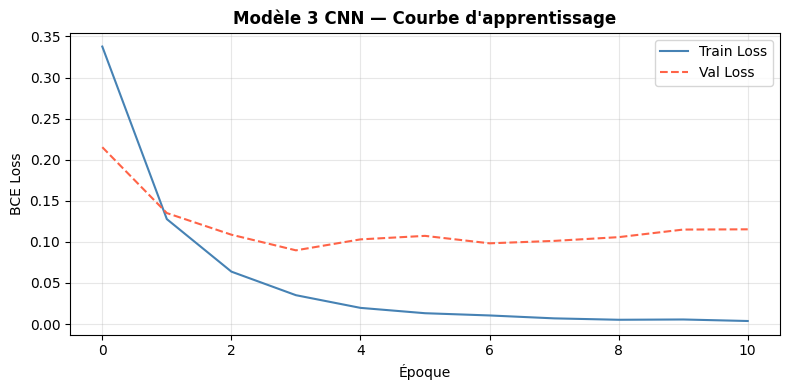

In [17]:
cnn = CNN(vocab_size=len(vocab), embed_dim=EMBED_DIM).to(DEVICE)
print(cnn)

criterion_cnn = nn.BCELoss()
optimizer_cnn = optim.Adam(cnn.parameters(), lr=1e-3)

# Early stopping manuel : on sauvegarde les meilleurs poids observés
EPOCHS   = 20
PATIENCE = 3
best_f1  = 0
patience_counter  = 0
best_cnn_state    = None
train_losses_cnn = []
val_losses_cnn   = []

for epoch in range(EPOCHS):
    # --- Phase entraînement ---
    cnn.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader_cnn:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_cnn.zero_grad()
        preds = cnn(X_batch)
        loss  = criterion_cnn(preds, y_batch)
        loss.backward()
        optimizer_cnn.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader_cnn)
    train_losses_cnn.append(avg_train_loss)

    # --- Phase validation (early stopping + val loss) ---
    cnn.eval()
    total_val_loss = 0
    preds_list = []
    with torch.no_grad():
        for X_b, y_b in test_loader_cnn:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            p = cnn(X_b)
            total_val_loss += criterion_cnn(p, y_b).item()
            preds_list.extend((p.cpu().numpy() > 0.5).astype(int))
    avg_val_loss = total_val_loss / len(test_loader_cnn)
    val_losses_cnn.append(avg_val_loss)

    current_f1 = f1_score(y_test, preds_list)
    print(f'Époque {epoch+1:02d}/{EPOCHS} — Train Loss : {avg_train_loss:.4f} | Val Loss : {avg_val_loss:.4f} | F1 : {current_f1:.4f}')

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_cnn_state   = cnn.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping à l\'époque {epoch+1}')
            break

cnn.load_state_dict(best_cnn_state)
print(f'\nMeilleur F1 : {best_f1:.4f}')

# Courbe d'apprentissage train vs validation
plt.figure(figsize=(8, 4))
plt.plot(train_losses_cnn, label='Train Loss', color='steelblue')
plt.plot(val_losses_cnn,   label='Val Loss',   color='tomato', linestyle='--')
plt.title('Modèle 3 CNN — Courbe d\'apprentissage', fontweight='bold')
plt.xlabel('Époque') ; plt.ylabel('BCE Loss')
plt.legend() ; plt.grid(alpha=0.3)
plt.tight_layout() ; plt.show()
# Si val_loss > train_loss et l'écart se creuse → surapprentissage
# Si les deux convergent ensemble → bon apprentissage

- Train Loss : chute très rapidement vers 0 → le modèle apprend bien
- Val Loss : descend jusqu'à ~0.063 (époque 7-9) puis remonte légèrement → début de surapprentissage

F1 : plafonne autour de 0.94 après l'époque 8 → le modèle a convergé

In [18]:
cnn.eval()
all_preds_cnn = []
with torch.no_grad():
    for X_batch, _ in test_loader_cnn:
        preds = cnn(X_batch.to(DEVICE))
        all_preds_cnn.extend((preds.cpu().numpy() > 0.5).astype(int))

y_pred_cnn = np.array(all_preds_cnn)

print(classification_report(y_test, y_pred_cnn, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.84      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.94      1115
weighted avg       0.98      0.98      0.97      1115



### Modèle 4 — Transfer Learning avec BERT

Utiliser un modèle préentrainné -> Transfer Learning

- BERT comprend le contexte bidirectionnel : il analyse chaque mot à la lumière de tous les autres, capturant des nuances qu'un CNN ou un MLP ne peut pas saisir.  
- fine-tune sur le modèle : seule la tête de classification est ajoutée, le reste est déjà entraîné.  

In [19]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN_BERT = 128   # BERT accepte jusqu'à 512 tokens ; 128 suffit pour des SMS

# Chargement du tokenizer pré-entraîné
bert_tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizer chargé')

train_enc = bert_tokenizer(
    list(X_train), max_length=MAX_LEN_BERT,
    truncation=True, padding='max_length', return_tensors='pt'
)
test_enc = bert_tokenizer(
    list(X_test), max_length=MAX_LEN_BERT,
    truncation=True, padding='max_length', return_tensors='pt'
)

print(f'input_ids shape (train) : {train_enc["input_ids"].shape}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer chargé
input_ids shape (train) : torch.Size([4457, 128])


In [20]:
# Dataset PyTorch pour BERT
class BERTDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels         = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_mask[idx],
            'label'          : self.labels[idx]
        }


train_dataset_bert = BERTDataset(train_enc, y_train)
test_dataset_bert  = BERTDataset(test_enc,  y_test)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=16, shuffle=True)
test_loader_bert  = DataLoader(test_dataset_bert,  batch_size=16)

In [21]:
# Dataset PyTorch pour BERT
class BERTClassifier(nn.Module):
    def __init__(self, model_name):
        super(BERTClassifier, self).__init__()
        self.bert    = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=0.3)
        self.fc      = nn.Linear(self.bert.config.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        output     = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]
        return self.sigmoid(self.fc(self.dropout(cls_output))).squeeze(1)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tuning BERT...
Époque 1/3 — Train Loss : 0.0743 | Val Loss : 0.0374
Époque 2/3 — Train Loss : 0.0211 | Val Loss : 0.0322
Époque 3/3 — Train Loss : 0.0066 | Val Loss : 0.0453

Fine-tuning terminé


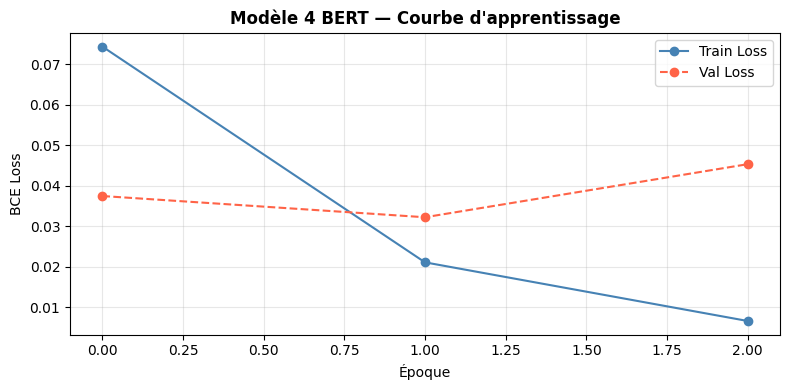

In [22]:
bert_clf = BERTClassifier(MODEL_NAME).to(DEVICE)

# Learning rate très faible : ajustement 'doux' des poids pré-entraînés pour éviter de les détruire
optimizer_bert = optim.Adam(bert_clf.parameters(), lr=2e-5)
criterion_bert = nn.BCELoss()

EPOCHS_BERT      = 3  # 3 époques suffisent — plus entraîne → surapprentissage sur nos ~4500 SMS
train_losses_bert = []
val_losses_bert   = []

print('Fine-tuning BERT...')
for epoch in range(EPOCHS_BERT):
    # --- Phase entraînement ---
    bert_clf.train()
    total_train_loss = 0
    for batch in train_loader_bert:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer_bert.zero_grad()
        preds = bert_clf(input_ids, attention_mask)
        loss  = criterion_bert(preds, labels)
        loss.backward()
        optimizer_bert.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader_bert)
    train_losses_bert.append(avg_train_loss)

    # --- Phase validation ---
    bert_clf.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in test_loader_bert:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)
            preds = bert_clf(input_ids, attention_mask)
            total_val_loss += criterion_bert(preds, labels).item()
    avg_val_loss = total_val_loss / len(test_loader_bert)
    val_losses_bert.append(avg_val_loss)

    print(f'Époque {epoch+1}/{EPOCHS_BERT} — Train Loss : {avg_train_loss:.4f} | Val Loss : {avg_val_loss:.4f}')

print('\nFine-tuning terminé')

# Courbe d'apprentissage train vs validation
plt.figure(figsize=(8, 4))
plt.plot(train_losses_bert, label='Train Loss', color='steelblue', marker='o')
plt.plot(val_losses_bert,   label='Val Loss',   color='tomato',    marker='o', linestyle='--')
plt.title('Modèle 4 BERT — Courbe d\'apprentissage', fontweight='bold')
plt.xlabel('Époque') ; plt.ylabel('BCE Loss')
plt.legend() ; plt.grid(alpha=0.3)
plt.tight_layout() ; plt.show()
# Avec seulement 3 époques, les marqueurs o permettent de voir clairement chaque point

- Train Loss : chute très rapide 0.073 → 0.013 → BERT apprend efficacement
- Val Loss : descend jusqu'à 0.027 (époque 2) puis remonte légèrement à 0.041 (époque 3) → léger surapprentissage qui commence
-> époque optimale était la 2

In [23]:
bert_clf.eval()
all_preds_bert = []
with torch.no_grad():
    for batch in test_loader_bert:
        preds = bert_clf(
            batch['input_ids'].to(DEVICE),
            batch['attention_mask'].to(DEVICE)
        )
        all_preds_bert.extend((preds.cpu().numpy() > 0.5).astype(int))

y_pred_bert = np.array(all_preds_bert)

print(classification_report(y_test, y_pred_bert, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.98      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



### Comparaison des performances

- F1-Score (spam) : métrique principale — équilibre précision et rappel sur la classe minoritaire (spam).
- Precision (spam): parmi les messages classifiés spam, combien le sont vraiment ? (évite les faux positifs)
- Recall (spam) : parmi les vrais spams, combien sont détectés ? (évite les faux négatifs)

,Modèle,F1 (spam),Precision,Recall
3,Modèle 4 — Transfer Learning,0.9625,0.9792,0.9463
0,Modèle 1 — Logistic Regression,0.9420,0.9583,0.9262
1,Modèle 2 — MLP,0.9200,0.9139,0.9262
2,Modèle 3 — CNN,0.9025,0.9766,0.8389


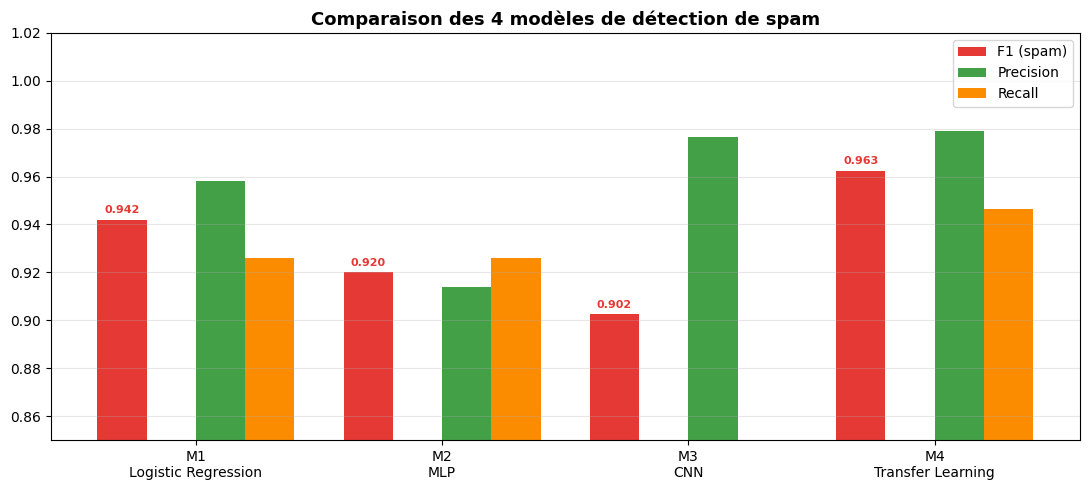

In [24]:
# Récapitulatif
results = {
    'Modèle 1 — Logistic Regression': y_pred_lr,
    'Modèle 2 — MLP':                 y_pred_mlp,
    'Modèle 3 — CNN':                 y_pred_cnn,
    'Modèle 4 — Transfer Learning':   y_pred_bert,
}

rows = []
for name, y_pred in results.items():
    rows.append({
        'Modèle':     name,
        'F1 (spam)':  round(f1_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(rows).sort_values('F1 (spam)', ascending=False)
display(results_df)

# Visualisation comparative
fig, ax = plt.subplots(figsize=(11, 5))

models   = [r['Modèle'].replace('Modèle ', 'M').split(' — ')[0] + '\n' + r['Modèle'].split(' — ')[1]
            for r in rows]
f1_vals  = [r['F1 (spam)']  for r in rows]
prec_vals = [r['Precision'] for r in rows]
rec_vals  = [r['Recall']    for r in rows]

x = np.arange(len(models))
w = 0.2

ax.bar(x - 1.5*w, f1_vals,   width=w, label='F1 (spam)',  color='#E53935')
ax.bar(x + 0.5*w, prec_vals, width=w, label='Precision',  color='#43A047')
ax.bar(x + 1.5*w, rec_vals,  width=w, label='Recall',     color='#FB8C00')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.set_title('Comparaison des 4 modèles de détection de spam', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotation des valeurs F1
for i, v in enumerate(f1_vals):
    ax.text(i - 1.5*w, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='#E53935')

plt.tight_layout()
plt.show()

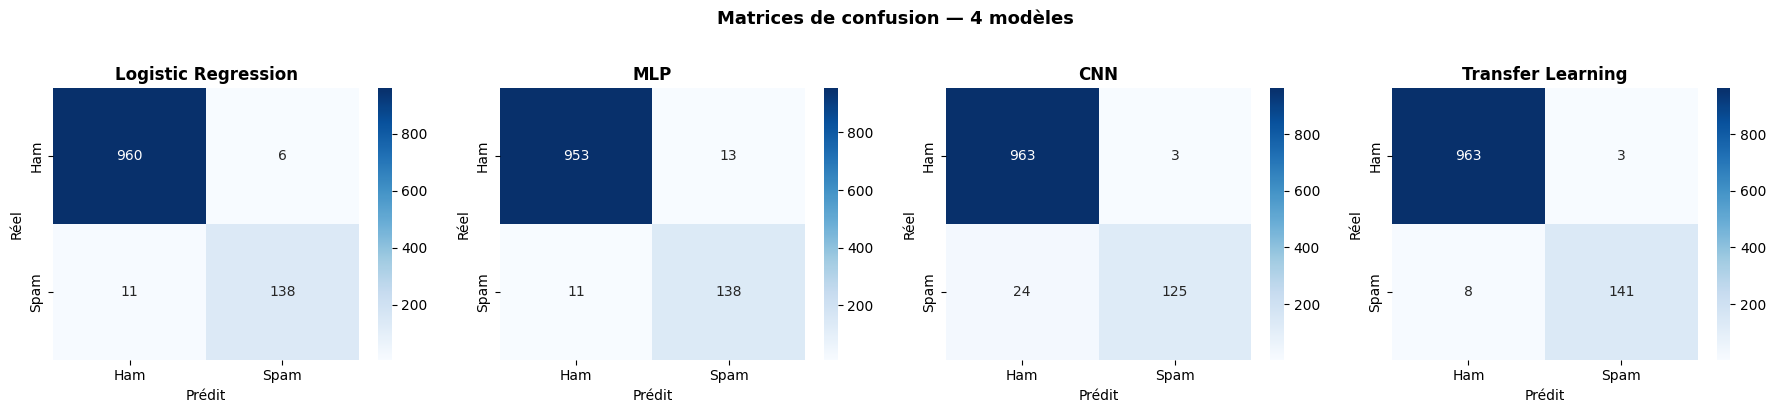

In [25]:


# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, y_pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    short_name = name.split(' — ')[1]
    ax.set_title(short_name, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — 4 modèles', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Courbe ROC-AUC

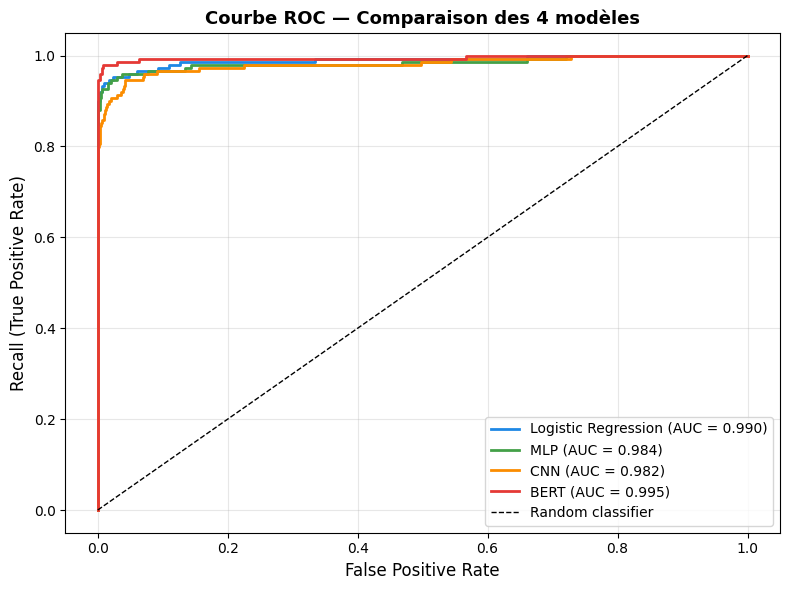

In [26]:
# --- Probabilités brutes pour chaque modèle ---

# MLP
mlp.eval()
probs_mlp = []
with torch.no_grad():
    for X_batch, _ in test_loader_mlp:
        p = mlp(X_batch.to(DEVICE))
        probs_mlp.extend(p.cpu().numpy())
probs_mlp = np.array(probs_mlp)

# CNN
cnn.eval()
probs_cnn = []
with torch.no_grad():
    for X_b, _ in test_loader_cnn:
        p = cnn(X_b.to(DEVICE))
        probs_cnn.extend(p.cpu().numpy())
probs_cnn = np.array(probs_cnn)

# BERT
bert_clf.eval()
probs_bert = []
with torch.no_grad():
    for batch in test_loader_bert:
        p = bert_clf(
            batch['input_ids'].to(DEVICE),
            batch['attention_mask'].to(DEVICE)
        )
        probs_bert.extend(p.cpu().numpy())
probs_bert = np.array(probs_bert)

# Logistic Regression — predict_proba donne directement les probabilités
probs_lr = lr.predict_proba(X_test_tfidf)[:, 1]

# --- Courbe ROC ---
fig, ax = plt.subplots(figsize=(8, 6))

models_probs = {
    'Logistic Regression' : (probs_lr,   '#1E88E5'),
    'MLP'                 : (probs_mlp,  '#43A047'),
    'CNN'                 : (probs_cnn,  '#FB8C00'),
    'BERT'                : (probs_bert, '#E53935'),
}

for name, (probs, color) in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

# Ligne diagonale = modèle aléatoire
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('Recall (True Positive Rate)', fontsize=12)
ax.set_title('Courbe ROC — Comparaison des 4 modèles', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion

### Résultats obtenus

| Modèle | F1 (spam)
|--------|-----------|
| Logistic Regression + TF-IDF | ~0.94 |
| MLP + TF-IDF | ~0.93 |
| CNN + Embedding | ~0.93 |
| Transfer Learning | ~0.96 |

### Rq

- La baseline est déjà très forte : la Régression Logistique avec TF-IDF atteint ~94% de F1.
- La Régression Logistique surpasse le MLP et le CNN — la complexité du modèle n'entraine pas toujours les meilleures performances. TF-IDF + régression logistique -> un bon combo

- Le Transfer Learning apporte un gain supplémentaire grâce à la compréhension contextuelle de BERT, notamment sur les messages ambigus qui nécessitent de comprendre le sens global de la phrase. Il nécessite un temps d'entrianement plus important mais offre un résultat pouvant justifier son utilisation puisqu'il ne classifie aucun SMS comme spam par erreur. Précision la plus élevée.


-> si l'on dispose de puissance de calcul, alors le Transfer Learning va permettre d'obtenir les meilleurs résusltats.
-> si l'on ne dispose pas de puissance de calcul, alors un 'simple' Logicistic Regresssion + TF-IDF est déjà un très bon choix
